# Filtering data in 1D

In [ ]:
# %load_ext autoreload
# %autoreload 2

import cmocean
import pandas as pd
import verde as vd

import airbornegeo

In [ ]:
data_df = pd.read_csv("data/AGAP_gravity_survey_processed.csv")
data_df = data_df[
    [
        "easting",
        "northing",
        "line",
        "unixtime",
        "grav_disturbance",
        "distance_along_line",
    ]
]
data_df = data_df.sort_values(["line", "unixtime"]).reset_index(drop=True)
data_df.head()

,easting,northing,line,unixtime,grav_disturbance,distance_along_line
0,1.000024e+06,226237.330771,1,1.229507e+09,1186.4,0.000000
1,1.000083e+06,226246.631269,1,1.229507e+09,342.1,59.842447
2,1.000142e+06,226255.809132,1,1.229507e+09,-1965.9,119.693401
3,1.000201e+06,226264.969079,1,1.229507e+09,820.0,179.545645
4,1.000260e+06,226274.156809,1,1.229507e+09,3198.0,239.285174


## Filter a line

In [7]:
# extract a single line from the survey
line_df = data_df[data_df.line == 4]

### Spatial filtering
We can perform 1D filtering based on the distance along the flight line. 

In [10]:
line_df["grav_disturbance_filtered_spatial"] = airbornegeo.filter_line(
    line_df,
    filter_type="g19000+l",  # 19 km low pass gaussian filter
    data_column="grav_disturbance",
    filter_by_column="distance_along_line",
    pad_width_percentage=10,
)

Text(0, 0.5, 'mGal')

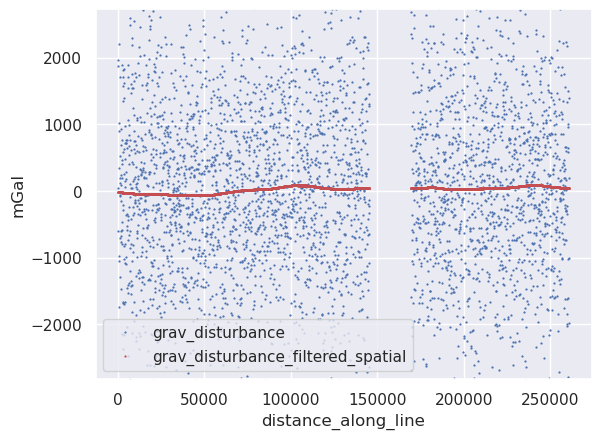

In [17]:
ylim = vd.minmax(line_df.grav_disturbance, min_percentile=2, max_percentile=98)
ax = line_df.plot.line(
    "distance_along_line",
    "grav_disturbance",
    style="bp",
    ms=0.6,
    ylim=ylim,
)
ax = line_df.plot.line(
    "distance_along_line",
    "grav_disturbance_filtered_spatial",
    style="rp",
    ms=0.6,
    ax=ax,
    ylim=ylim,
)
ax.set_ylabel("mGal")

In [18]:
line_df = line_df.sort_values("unixtime")

line_df["grav_disturbance_filtered_temporal"] = airbornegeo.filter_line(
    line_df,
    filter_type="g400+l",  # 400 sec low pass gaussian filter
    data_column="grav_disturbance",
    filter_by_column="unixtime",
    pad_width_percentage=10,
)

Text(0, 0.5, 'mGal')

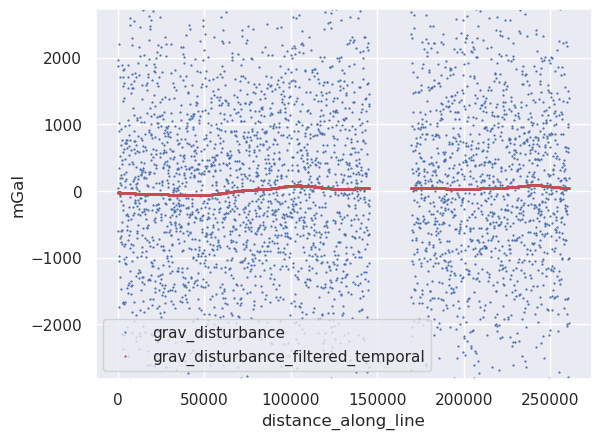

In [19]:
ylim = vd.minmax(line_df.grav_disturbance, min_percentile=2, max_percentile=98)
ax = line_df.plot.line(
    "distance_along_line",
    "grav_disturbance",
    style="bp",
    ms=0.6,
    ylim=ylim,
)
ax = line_df.plot.line(
    "distance_along_line",
    "grav_disturbance_filtered_temporal",
    style="rp",
    ms=0.6,
    ax=ax,
    ylim=ylim,
)
ax.set_ylabel("mGal")

Text(0, 0.5, 'mGal')

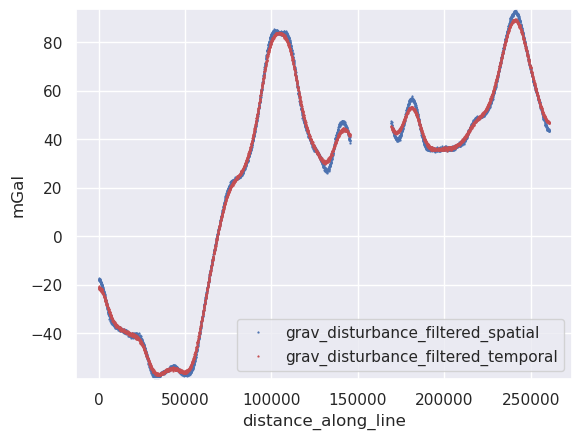

In [27]:
ylim = vd.minmax(
    line_df[
        ["grav_disturbance_filtered_spatial", "grav_disturbance_filtered_temporal"]
    ],
)
ax = line_df.plot.line(
    "distance_along_line",
    "grav_disturbance_filtered_spatial",
    style="bp",
    ms=0.6,
    ylim=ylim,
)
ax = line_df.plot.line(
    "distance_along_line",
    "grav_disturbance_filtered_temporal",
    style="rp",
    ms=0.6,
    ax=ax,
    ylim=ylim,
)
ax.set_ylabel("mGal")

## Filter all lines in a survey

### Spatial filtering

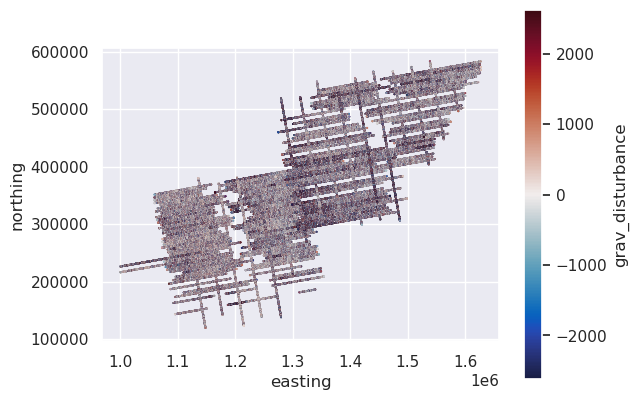

In [33]:
# plot the unfiltered gravity disturbance data
max_abs = vd.maxabs(line_df.grav_disturbance, percentile=95)
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="grav_disturbance",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
)
ax.set_aspect("equal")

In [34]:
data_df["grav_disturbance_filtered_spatial"] = airbornegeo.filter_line(
    data_df,
    filter_type="g19000+l",  # 19 km low pass gaussian filter
    data_column="grav_disturbance",
    filter_by_column="distance_along_line",
    groupby_column="line",
    pad_width_percentage=10,
)

Segments: 100%|██████████| 100/100 [00:03<00:00, 31.87it/s]


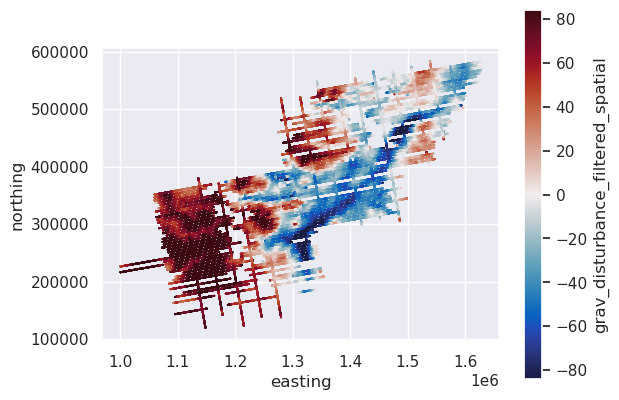

In [35]:
# plot the filtered gravity disturbance data
max_abs = vd.maxabs(line_df.grav_disturbance_filtered_spatial, percentile=95)
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="grav_disturbance_filtered_spatial",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
)
ax.set_aspect("equal")

### Temporal filtering

In [36]:
data_df["grav_disturbance_filtered_temporal"] = airbornegeo.filter_line(
    data_df,
    filter_type="g500+l",  # 500 sec low pass gaussian filter
    data_column="grav_disturbance",
    filter_by_column="unixtime",
    groupby_column="line",
    pad_width_percentage=10,
)

Segments: 100%|██████████| 100/100 [00:04<00:00, 23.94it/s]


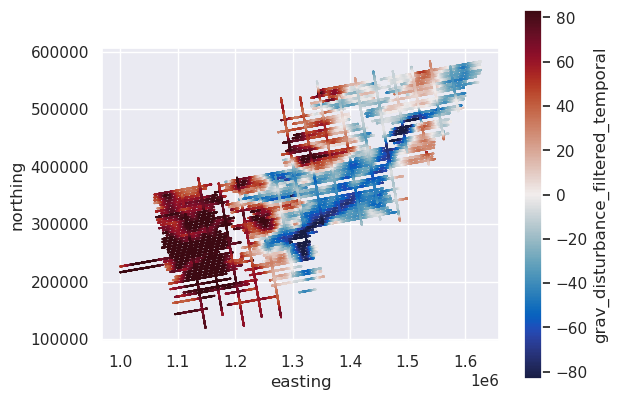

In [37]:
# plot the filtered gravity disturbance data
max_abs = vd.maxabs(line_df.grav_disturbance_filtered_temporal, percentile=95)
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="grav_disturbance_filtered_temporal",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
)
ax.set_aspect("equal")